In [1]:
"Option pricing models - Heston Model FFT"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy import sparse
from scipy.fft import fft
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.integrate import quad
from scipy.interpolate import RectBivariateSpline
import scipy.linalg as linalg
import scipy.optimize as optimize

import warnings
warnings.filterwarnings('ignore')

In [2]:
# --- Option Pricing Calculations ---

# --- 1. Define Heston Model Parameters and Option Details ---

# Model parameters
v0 = 0.04       # Initial variance (20% volatility)
theta = 0.04    # Long-run variance
kappa = 2.0     # Speed of mean reversion
sigma = 0.3     # Volatility of variance
rho = -0.7      # Correlation between asset and variance (typically negative)
#Market parameters
S0 = 100.0      # Initial stock price
K = 80.0        # Strike price
T = 1.0         # Time to maturity (1 year)
r = 0.03        # Risk-free rate (3%)
q = 0.02        # Dividend yield (2%)

In [3]:
# --- 2. Define the Heston Characteristic Function ---

def char_func_heston(u, T, r, q, v0, theta, kappa, sigma, rho, stable=True):
    
    if stable==True:
        """
        Computes the Heston characteristic function using a numerically stable formulation
        """
        # This version uses hyperbolic functions for improved numerical stability
        # Numerically stable calculation of C and D

        i = 1j  # Imaginary unit
        
        # Common terms
        beta = kappa - rho * sigma * i * u
        d = np.sqrt(beta**2 + sigma**2 * (u**2 + i * u))
        d_t_half = d * T / 2.0
        
        # Handle the case where d_t_half is very small to avoid division by zero in sinh
        # For small x, sinh(x) approx x and cosh(x) approx 1
        # This prevents NaN values for u=0
        small_d_mask = np.abs(d_t_half) < 1e-10
        
        # Calculate sinh and cosh safely
        sinh_d_tau_half = np.sinh(d_t_half)
        cosh_d_tau_half = np.cosh(d_t_half)
        # Note: coth(x) = 1/tanh(x) = cosh(x)/sinh(x)
        """
        # Avoid numerical issues when d*T is very small
        if np.abs(d_half_T) < 1e-8:
            # Use Taylor expansion for small arguments
            sinh_d_tau_half = d_t_half * (1 + (d_t_half)**2 / 6)
            cosh_d_tau_half = 1 + (d_t_half)**2 / 2
        else:
            sinh_d_tau_half = np.sinh(d_t_half)
            cosh_d_tau_half = np.cosh(d_t_half)
        """

        # D term
        # When d is small, d*coth(d*T/2) -> 2/T
        D_val = -(u**2 + i * u) / (beta + d * cosh_d_tau_half / sinh_d_tau_half)
        D_val[small_d_mask] = -(u[small_d_mask]**2 + i * u[small_d_mask]) / (beta[small_d_mask] + 2.0/T)

        # C term
        # When d is small, the log term simplifies
        log_term = cosh_d_tau_half + (beta / d) * sinh_d_tau_half
        log_term[small_d_mask] = 1.0 # Log(1)=0, so the term vanishes
        
        C_val = (kappa * theta / sigma**2) * (beta * T - 2 * np.log(log_term))

        # The characteristic function (forward carries the dividend yield q: drift = r - q)
        phi = np.exp(C_val + D_val * v0 + i * u * (np.log(S0) + (r - q) * T))
    
    else:
        """
        Computes the Heston characteristic function
        """
        i = 1j  # Imaginary unit
        
        # Calculate d and g
        beta = kappa - rho * sigma * i * u
        d = np.sqrt((rho * sigma * i * u - kappa)**2 + sigma**2 * (u**2 + i * u))
        g = (beta - d) / (beta + d)

        # Calculate C and D
        C = ((kappa * theta / sigma**2) * ((beta - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g))))
        D = ((beta - d) / sigma**2) * ((1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T)))

        # The characteristic function (forward carries the dividend yield q: drift = r - q)
        phi = np.exp(C + D * v0 + (i * u) * ((r - q) * T + np.log(S0)))
        
    return phi

# --- 3. Implement the FFT-based Pricing Method ---
# This function calls the stable characteristic function

def price_call_heston_fft(S0, T, r, q, v0, theta, kappa, sigma, rho, N = 2**12, eta = 0.25, alpha = 1.5, simpson=True):
    """
    Prices European call options using the Heston model and FFT.
    Returns a range of strikes and their corresponding call prices.

    K: Strike price
    T: Time to maturity
    q: Dividend yield (enters the forward drift as r - q)
    N: Number of points for FFT
    alpha: Damping parameter
    # FFT parameters
    N = 2**12             # Number of points, should be a power of 2
    alpha = 1.5           # Dampening factor for integrability
    eta = 0.25            # Grid spacing in Fourier domain
    """

    i = 1j  # Imaginary unit
    lambda_ = (2 * np.pi) / (N * eta)  # Step-size in log strike space

    # Grids
    v = np.arange(N) * eta # Integration points
    #k = np.log(S0) - (N / 2) * lambda_ + np.arange(N) * lambda_  # Strike price range
    k = -(N * lambda_ / 2) + lambda_ * np.arange(N)
    strikes = np.exp(k)
    
    # Calculate the Fourier transform of the call price
    u_for_psi = v - (alpha + 1) * i
    numerator = np.exp(-r * T) * char_func_heston(u_for_psi, T, r, q, v0, theta, kappa, sigma, rho)
    denominator = (alpha + i * v) * (alpha + 1 + i * v)
    psi = numerator / denominator # Damping function

    if simpson == True:
        # Simpson's rule weights
        # Apply Simpson's rule weighting for better accuracy
        simpson_weights = (eta / 3) * (3 + (-1)**(np.arange(N) + 1) - (np.arange(N) == 0))
        fft_input = np.exp(i * v * (N / 2) * lambda_) * psi * simpson_weights
            
    else:
        eta = np.full(N, eta)
        fft_input = np.exp(i * v * (N / 2) * lambda_) * psi * eta

    # FFT
    call_prices_fft = np.fft.fft(fft_input)
    
    call_prices = np.exp(-alpha * k) / np.pi * np.real(call_prices_fft)
    #call_prices = np.exp(-alpha * k) * np.real(call_prices_fft) / np.pi
    
    return strikes, call_prices


Heston Model Parameters:
v0=0.04, theta=0.04, kappa=2.0, sigma=0.3, rho=-0.7, r=0.03, T=1.0

Price for an at-the-money (K=100) call option: 7.9832


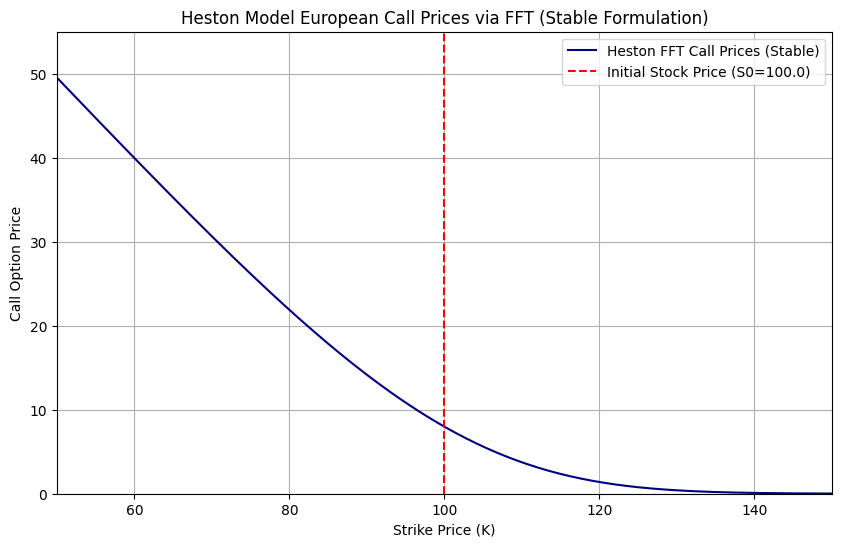

In [4]:
# --- 4. Price the option and visualize the results ---

if __name__ == '__main__':
    # Get the prices for a range of strikes using the stable method
    strikes, call_prices = price_call_heston_fft(S0, T, r, q, v0, theta, kappa, sigma, rho)
    
    # Find the price for an at-the-money strike (K=100)
    atm_strike = 100
    atm_price = np.interp(atm_strike, strikes, call_prices)
    print(f"Heston Model Parameters:")
    print(f"v0={v0}, theta={theta}, kappa={kappa}, sigma={sigma}, rho={rho}, r={r}, T={T}\n")
    print(f"Price for an at-the-money (K={atm_strike}) call option: {atm_price:.4f}")

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(strikes, call_prices, label='Heston FFT Call Prices (Stable)', color='navy')
    plt.axvline(x=S0, color='r', linestyle='--', label=f'Initial Stock Price (S0={S0})')
    plt.xlabel('Strike Price (K)')
    plt.ylabel('Call Option Price')
    plt.title('Heston Model European Call Prices via FFT (Stable Formulation)')
    plt.grid(True)
    plt.legend()
    plt.xlim([50, 150])
    plt.ylim([0, 55])
    plt.show()

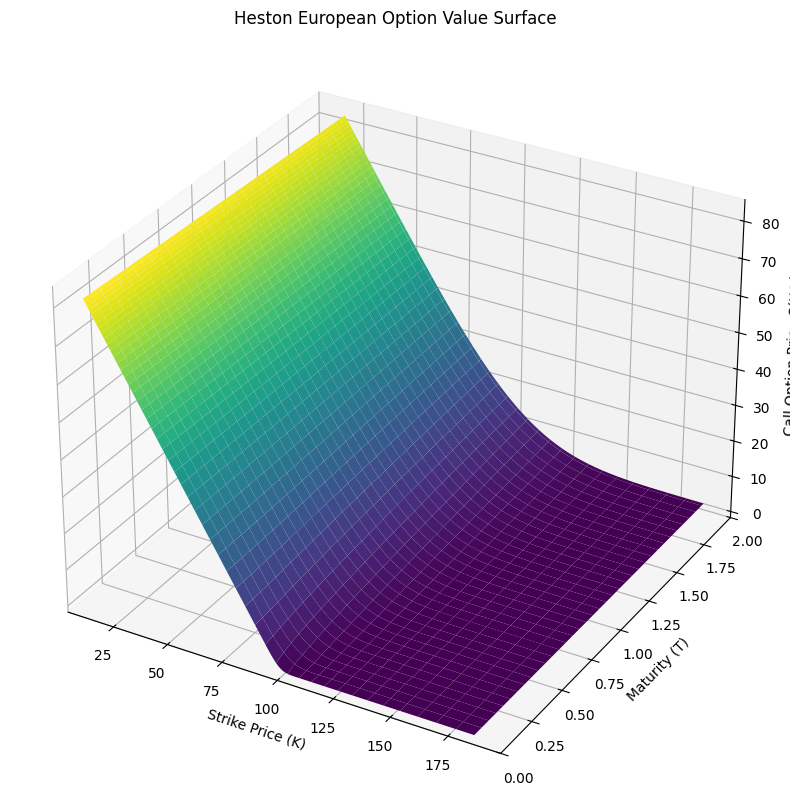

In [5]:
# --- 5. Visualize the Option Value Surface ---

maturities = np.linspace((1/52), 2.0, 104)
prices = np.zeros((len(maturities), 2**12))

for n, T_n in enumerate(maturities):
    strike_grid, call_prices = price_call_heston_fft(S0, T_n, r, q, v0, theta, kappa, sigma, rho)
    prices[n, :] = np.array(call_prices)

prices = prices[:, 2500:2900]
strike_grid = strike_grid[2500:2900]

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
#K_mesh, T_mesh = np.meshgrid(strike_grid, maturities, indexing='ij')
K_mesh, T_mesh = np.meshgrid(strike_grid, maturities)

ax.plot_surface(K_mesh, T_mesh, prices, cmap='viridis')
ax.set_title("Heston European Option Value Surface")
ax.set_xlabel("Strike Price (K)")
ax.set_ylabel("Maturity (T)")
ax.set_zlabel("Call Option Price C(K,T)")
#ax.set_xlim(25, 150)
ax.set_ylim(0, 2)
#ax.set_zlim(0, 100)
plt.show()

In [6]:
# --- Model Calibration ---

# --- 1. Create Synthetic Market Data ---

# These are the "true" parameters we are trying to find
true_params = {'v0': 0.03, 'theta': 0.03, 'kappa': 1.5, 'sigma': 0.25, 'rho': -0.6}

# Define market instruments (strikes and maturities)
market_maturities = [0.25, 0.5, 1.0, 1.25, 1.5, 1.75, 2.0]
market_strikes = [60, 70, 80, 90, 100, 110, 120, 130, 140]

market_data = []
for T in market_maturities:
    # Generate clean prices with the true parameters
    strikes, call_prices = price_call_heston_fft(S0, T, r, q, true_params['v0'], true_params['theta'], 
                                                 true_params['kappa'], true_params['sigma'], true_params['rho'])
    # Interpolate to get prices for the specific strikes we need
    interp_func = interp1d(strikes, call_prices, kind='cubic', fill_value="extrapolate")
    clean_prices = interp_func(market_strikes)

    # Add some noise to simulate a real market
    noisy_prices = clean_prices + np.random.normal(0, 0.1, len(clean_prices))
    for K, price in zip(market_strikes, noisy_prices):
        market_data.append({'Maturity': T, 'Strike': K, 'Price': price})

market_df = pd.DataFrame(market_data)
print("--- Synthetic Market Data ---")
print(market_df)
print("\n")


--- Synthetic Market Data ---
    Maturity  Strike      Price
0       0.25      60  40.051736
1       0.25      70  30.023075
2       0.25      80  20.122452
3       0.25      90  10.800128
4       0.25     100   3.361660
..       ...     ...        ...
58      2.00     100   9.834149
59      2.00     110   5.736347
60      2.00     120   2.862742
61      2.00     130   1.435721
62      2.00     140   0.424817

[63 rows x 3 columns]




In [7]:
# --- 2. Find Optimal Parameter Starting Point ---

params1 = (0.1, 0.01, 0.5, 0.05, -0.3)
params2 = (0.01, 0.1, 4.0, 0.5, -0.9)

iArray = []
rmseArray = []
rmseMin = 1e10

def rmse_ht(params, market_df=market_df, S0=S0, r=r, q=q):
    total_error = 0.0
    v0, theta, kappa, sigma, rho = params

    # One FFT per maturity (it returns the whole strike curve), then interpolate the needed strikes
    for T, group in market_df.groupby('Maturity'):
        model_strikes, call_prices = price_call_heston_fft(S0, T, r, q, v0, theta, kappa, sigma, rho)
        model_prices = np.interp(group['Strike'].values, model_strikes, call_prices)
        total_error += np.sum((model_prices - group['Price'].values)**2)

    #for index, option in market_df.iterrows():
        #T = option['Maturity']
        #K = option['Strike']
        #market_price = option['Price']

        # Calculate model prices for this maturity
        #model_strikes, call_prices = price_call_heston_fft(S0, T, r, q, v0, theta, kappa, sigma, rho)
        #model_price = np.interp(K, model_strikes, call_prices)
        
        # Add squared error to the total
        #total_error += (model_price - market_price)**2

    # We want to minimize the mean squared error
    mse = total_error / len(market_df)
    rmse = np.sqrt(mse)
    
    return rmse

for i in np.arange(0, 1.05, 0.05):

    params = i*np.array(params1) + (1.0-i)*np.array(params2)
    iArray.append(i)

    rmse = rmse_ht(params, market_df, S0, r) 
    rmseArray.append(rmse)
    if (rmse < rmseMin):
        rmseMin = rmse
        optimParams = params

print(rmseMin)
print(optimParams)


1.6284651260882694
[ 0.0685  0.0415  1.725   0.2075 -0.51  ]


In [8]:
# --- 3. Define the Objective Function for Calibration ---

"""
BFGS is a powerful gradient-based method, however the Heston objective function can be challenging.
It's often non-convex and may have many local minima.
Alternative: Nelder-Mead (Simplex Method)
A gradient-free method (doesn't require derivatives). It maintains a geometric shape called a simplex 
in the parameter space and iteratively reflects, expands, or contracts it to "crawl" towards a minimum.
"""

def objective_function(params, S0, r, market_df):
    v0, theta, kappa, sigma, rho = params

    # Enforce bounds manually since Nelder-Mead doesn't support them.
    if not (1e-4 < v0 < 0.5 and 1e-4 < theta < 0.5 and 0.1 < kappa < 5.0 and 0.05 < sigma < 1.0 and -0.99 < rho < 0.99):
        return 1e12 # Return a large penalty

    # Add a penalty for violating the Feller condition (2*kappa*theta > sigma**2)
    # feller_penalty = max(0, sigma**2 - 2 * kappa * theta) * 1e4
    
    total_error = 0.0

    # Group by maturity: one FFT per maturity, then interpolate the needed strikes
    for T, group in market_df.groupby('Maturity'):
        model_strikes, call_prices = price_call_heston_fft(S0, T, r, q, v0, theta, kappa, sigma, rho)
        strikes = group['Strike'].values
        market_prices = group['Price'].values
        model_prices = np.interp(strikes, model_strikes, call_prices)
        total_error += np.sum((model_prices - market_prices)**2)
        
    #for index, option in market_df.iterrows():
        #T = option['Maturity']
        #K = option['Strike']
        #market_price = option['Price']

        # Calculate model prices for this maturity (q is the global dividend yield)
        #model_strikes, call_prices = price_call_heston_fft(S0, T, r, q, v0, theta, kappa, sigma, rho)
        #model_price = np.interp(K, model_strikes, call_prices)
        ## Interpolate to get prices for the specific strikes we need
        ##interp_func = interp1d(model_strikes, call_prices, kind='cubic', fill_value="extrapolate")
        ##model_prices = interp_func(model_strikes)
        ##print(f"T={T}, K={K}, Market Price={market_price:.4f}, Model Price={model_price:.4f}")

        # Add squared error to the total
        #total_error += np.sum((model_price - market_price)**2)
    
    # We want to minimize the mean squared error
    mse = total_error / len(market_df)
    rmse = np.sqrt(mse)
    # rmse = np.sqrt(mse + feller_penalty)
    print(f"Params: [v0:{v0:.4f}, θ:{theta:.4f}, κ:{kappa:.4f}, σ:{sigma:.4f}, ρ:{rho:.4f}] | MSE: {mse:.6f}, | RMSE: {rmse:.6f}")
    return rmse


In [9]:
# --- 4. Run the Optimization ---

# Initial guess for the parameters
#initial_guess = [0.06, 0.05, 1.5, 0.4, -0.5]
#[ 0.0685  0.0415  1.725  0.2075  -0.51  ]
initial_guess = optimParams

# --- Run the BFGS Optimization ---

# Parameter bounds to ensure they are realistic
# (v0, theta, kappa, sigma > 0) and (-1 < rho < 1)
bounds = [(1e-4, 0.5), (1e-4, 0.5), (0.1, 5.0), (0.05, 1.0), (-0.99, 0.99)]

print("--- Starting Heston Model Calibration using L-BFGS-B ---")
result = optimize.minimize(
    objective_function,
    initial_guess,
    args=(S0, r, market_df),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 500, 'ftol': 1e-8} # Increase maxiter for real problems
)

# --- Run the Nelder-Mead Optimization ---

print("--- Starting Heston Model Calibration using Nelder-Mead ---")
result_nm = optimize.minimize(
    objective_function,
    initial_guess,
    args=(S0, r, market_df),
    method='Nelder-Mead',
    # The 'bounds' argument is removed as it's not supported
    options={'maxiter': 500, 'xatol': 1e-6, 'fatol': 1e-6, 'adaptive': True}
)

print("Final Calibration Results BFGS:" + str(result["x"]))
print("Final Calibration Results Nelder-Mead:" + str(result_nm["x"]))
params = result["x"]

--- Starting Heston Model Calibration using L-BFGS-B ---
Params: [v0:0.0685, θ:0.0415, κ:1.7250, σ:0.2075, ρ:-0.5100] | MSE: 2.651899, | RMSE: 1.628465
Params: [v0:0.0685, θ:0.0415, κ:1.7250, σ:0.2075, ρ:-0.5100] | MSE: 2.651899, | RMSE: 1.628465
Params: [v0:0.0685, θ:0.0415, κ:1.7250, σ:0.2075, ρ:-0.5100] | MSE: 2.651900, | RMSE: 1.628466
Params: [v0:0.0685, θ:0.0415, κ:1.7250, σ:0.2075, ρ:-0.5100] | MSE: 2.651899, | RMSE: 1.628465
Params: [v0:0.0685, θ:0.0415, κ:1.7250, σ:0.2075, ρ:-0.5100] | MSE: 2.651899, | RMSE: 1.628465
Params: [v0:0.0685, θ:0.0415, κ:1.7250, σ:0.2075, ρ:-0.5100] | MSE: 2.651899, | RMSE: 1.628465
Params: [v0:0.0685, θ:0.0415, κ:1.7250, σ:0.2075, ρ:-0.5100] | MSE: 2.651899, | RMSE: 1.628465
Params: [v0:0.0685, θ:0.0415, κ:1.7250, σ:0.2075, ρ:-0.5100] | MSE: 2.651899, | RMSE: 1.628465
Params: [v0:0.0685, θ:0.0415, κ:1.7250, σ:0.2075, ρ:-0.5100] | MSE: 2.651900, | RMSE: 1.628466
Params: [v0:0.0685, θ:0.0415, κ:1.7250, σ:0.2075, ρ:-0.5100] | MSE: 2.651899, | RMSE: 1.

In [10]:
# --- Implied Volatility ---

# --- 1. Define the Functions for Calculations ---

#v0, theta, kappa, sigma, rho = params
v0, theta, kappa, sigma, rho = [0.03, 0.03, 1.5, 0.6, -0.67]

def black_scholes_price(S0, K, T, r, q, sigma):
    """Black-Scholes call and put option prices, returned as (call, put)."""

    if sigma <= 0 or T <= 0:
        # Degenerate case: return the (discounted) intrinsic values as a (call, put) pair
        intrinsic_call = max(S0 * np.exp(-q * T) - K * np.exp(-r * T), 0)
        intrinsic_put = max(K * np.exp(-r * T) - S0 * np.exp(-q * T), 0)
        return intrinsic_call, intrinsic_put
    
    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    call_price = (S0 * np.exp(-q * T) * norm.cdf(d1) - 
                    K * np.exp(-r * T) * norm.cdf(d2))
    put_price = call_price - S0 * np.exp(-q * T) + K * np.exp(-r * T)

    return call_price, put_price

def price_diff(market_price, S0, K, T, r, q , sigma, option_type='call'):
    """Difference between market price and BS price"""
    
    bs_call, bs_put = black_scholes_price(S0, K, T, r, q, sigma)

    if option_type == 'call':
        bs_price = bs_call
    else:
        bs_price = bs_put

    return bs_price - market_price

def implied_volatility_newton_raphson(market_price, S0, K, T, r, q, option_type='call', 
                                      initial_guess=0.2, max_iterations=100, tolerance=1e-6):
    """
    Calculate implied volatility using Newton-Raphson method
    This is the most efficient method for single options
    """

    def vega(sigma):
        """Black-Scholes Vega (∂Price/∂σ)"""
        if sigma <= 0 or T <= 0:
            return 1e-8
        
        d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        return S0 * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)
    
    sigma = initial_guess
    
    for i in range(max_iterations):
        price_error = price_diff(market_price, S0, K, T, r, q, sigma, option_type)
        
        if abs(price_error) < tolerance:
            return sigma
        
        vega_value = vega(sigma)
        if abs(vega_value) < 1e-10:
            break
        
        # Newton-Raphson update
        sigma_new = sigma - price_error / vega_value
        
        # Keep sigma positive and reasonable
        sigma_new = max(0.001, min(sigma_new, 5.0))
        
        if abs(sigma_new - sigma) < tolerance:
            return sigma_new
        
        sigma = sigma_new
    
    return sigma  # Return best guess if not converged

def implied_volatility_bisection(market_price, S0, K, T, r, q, option_type='call',
                                   vol_min=0.001, vol_max=3.0, tolerance=1e-6):
        """
        Calculate implied volatility using bisection method
        More robust but slower than Newton-Raphson
        """
        
        try:
            # Check if solution exists in the interval
            error_min = price_diff(market_price, S0, K, T, r, q , vol_min, option_type)
            error_max = price_diff(market_price, S0, K, T, r, q , vol_max, option_type)
            
            if error_min * error_max > 0:
                # No root in interval, return boundary value
                return vol_min if abs(error_min) < abs(error_max) else vol_max
            
            # Use scipy's brentq for robust bisection (root-find over sigma)
            implied_vol = optimize.brentq(
                lambda s: price_diff(market_price, S0, K, T, r, q, s, option_type),
                vol_min, vol_max, xtol=tolerance)
            return implied_vol
            
        except Exception:
            # Fallback to simple bisection
            vol_low, vol_high = vol_min, vol_max
            
            while vol_high - vol_low > tolerance:
                vol_mid = 0.5 * (vol_low + vol_high)
                error_mid = price_diff(market_price, S0, K, T, r, q , vol_mid, option_type)
                
                if abs(error_mid) < tolerance:
                    return vol_mid
                
                if error_mid * price_diff(market_price, S0, K, T, r, q , vol_low, option_type) < 0:
                    vol_high = vol_mid
                else:
                    vol_low = vol_mid
            
            return 0.5 * (vol_low + vol_high)

def heston_implied_volatility_surface(strike_range, time_range, S0, T, r, v0, theta, kappa, sigma, rho, method='newton_raphson'):
        """
        Generate implied volatility surface from Heston model
        
        strike_range: array of strike prices
        time_range: array of time to maturities
        method: 'newton_raphson' or 'bisection'
        """
        print(f"Generating {len(strike_range)}×{len(time_range)} implied volatility surface...")
        
        iv_surface_call = np.zeros((len(time_range), len(strike_range)))
        iv_surface_put = np.zeros((len(time_range), len(strike_range)))
        heston_prices_call = np.zeros((len(time_range), len(strike_range)))
        heston_prices_put = np.zeros((len(time_range), len(strike_range)))
        
        for i, T in enumerate(time_range):
            print(f"Processing maturity {i+1}/{len(time_range)}: T={T:.2f}y")
            
            for j, K in enumerate(strike_range):
                try:
                    # Get Heston prices (q is the global dividend yield)
                    strike_prices, call_price = price_call_heston_fft(S0, T, r, q, v0, theta, kappa, sigma, rho)
                    #log_strike = np.log(K)
                    #heston_call = np.interp(log_strike, k, call_price)
                    heston_call = np.interp(K, strike_prices, call_price)
                    heston_put = heston_call - S0 * np.exp(-q * T) + K * np.exp(-r * T)
                    heston_prices_call[i, j] = heston_call
                    heston_prices_put[i, j] = heston_put
                    
                    # Calculate implied volatilities
                    if method == 'newton_raphson':
                        iv_call = implied_volatility_newton_raphson(
                            heston_call, S0, K, T, r, q, 'call'
                        )
                        iv_put = implied_volatility_newton_raphson(
                            heston_put, S0, K, T, r, q, 'put'
                        )
                    else:  # bisection
                        iv_call = implied_volatility_bisection(
                            heston_call, S0, K, T, r, q, 'call'
                        )
                        iv_put = implied_volatility_bisection(
                            heston_put, S0, K, T, r, q, 'put'
                        )
                    
                    iv_surface_call[i, j] = iv_call
                    iv_surface_put[i, j] = iv_put
                    
                except Exception as e:
                    # Fill with reasonable values if calculation fails
                    iv_surface_call[i, j] = np.sqrt(v0)
                    iv_surface_put[i, j] = np.sqrt(v0)
                    heston_prices_call[i, j] = max(S0 - K * np.exp(-r * T), 0)
                    heston_prices_put[i, j] = max(K * np.exp(-r * T) - S0, 0)
        
        return iv_surface_call, iv_surface_put, heston_prices_call, heston_prices_put

Heston Model: Implied Volatility Analysis
Parameters: S0=$100.0, r=3.0%, q=2.0%
Heston: v0=0.0300, κ=1.75, θ=0.0300, σ=0.25, ρ=-0.66
Single Option Implied Volatility Example
------------------------------------------
Heston Call Price: $0.5060
Heston Put Price:  $36.2741

Implied Volatilities:
Call IV (Newton-Raphson): 13.93%
Put IV (Newton-Raphson):  13.93%
Call IV (Bisection):      13.93%
Put IV (Bisection):      13.93%
True instantaneous vol:   17.32%

Generating Implied Volatility Surface
----------------------------------------
Generating 9×9 implied volatility surface...
Processing maturity 1/9: T=0.20y
Processing maturity 2/9: T=0.30y
Processing maturity 3/9: T=0.40y
Processing maturity 4/9: T=0.50y
Processing maturity 5/9: T=0.60y
Processing maturity 6/9: T=0.70y
Processing maturity 7/9: T=0.80y
Processing maturity 8/9: T=0.90y
Processing maturity 9/9: T=1.00y

Implied Volatility Surface (Calls):
Strike\Time    0.20y    0.30y    0.40y    0.50y    0.60y    0.70y    0.80y    0.90

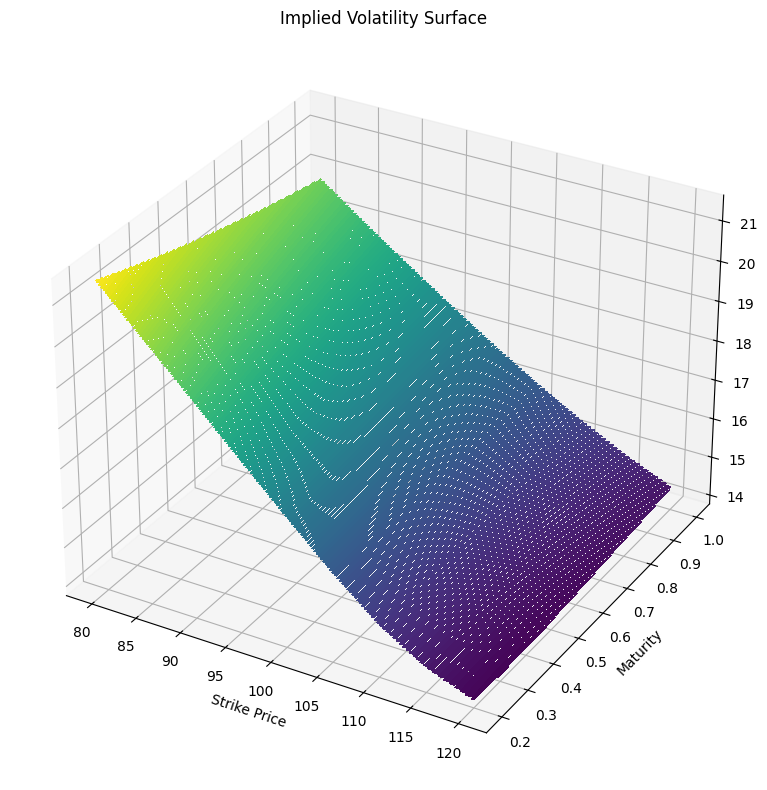

In [11]:
# --- 2. Run the Calculations ---

if __name__ == "__main__":
    """
    Demonstrate implied volatility extraction from Heston model
    """
    print("Heston Model: Implied Volatility Analysis")
    print("=" * 45)
    
    #S0, K, T, r, q = 100.0, 100.0, 0.25, 0.05, 0.02
    v0, theta, kappa, sigma, rho = [0.03, 0.03, 1.75, 0.25, -0.66]
    
    print(f"Parameters: S0=${S0}, r={r:.1%}, q={q:.1%}")
    print(f"Heston: v0={v0:.4f}, κ={kappa}, θ={theta:.4f}, σ={sigma}, ρ={rho}")
    
    # Single Option Implied Volatility
    print("Single Option Implied Volatility Example")
    print("-" * 42)
    
    # 1. Price option with Heston
    model_strikes, call_prices = price_call_heston_fft(S0, T, r, q, v0, theta, kappa, sigma, rho)
    heston_call_price = np.interp(K, model_strikes, call_prices)
    heston_put_price = heston_call_price - S0 * np.exp(-q * T) + K * np.exp(-r * T)
    
    print(f"Heston Call Price: ${heston_call_price:.4f}")
    print(f"Heston Put Price:  ${heston_put_price:.4f}")
    
    # 2. Extract implied volatilities
    iv_call_nr = implied_volatility_newton_raphson(
        heston_call_price, S0, K, T, r, q, 'call'
    )
    iv_put_nr = implied_volatility_newton_raphson(
        heston_put_price, S0, K, T, r, q, 'put'
    )

    iv_call_bis = implied_volatility_bisection(
        heston_call_price, S0, K, T, r, q, 'call'
    )
    iv_put_bis = implied_volatility_bisection(
        heston_put_price, S0, K, T, r, q, 'put'
    )
    
    print(f"\nImplied Volatilities:")
    print(f"Call IV (Newton-Raphson): {iv_call_nr:.2%}")
    print(f"Put IV (Newton-Raphson):  {iv_put_nr:.2%}")
    print(f"Call IV (Bisection):      {iv_call_bis:.2%}")
    print(f"Put IV (Bisection):      {iv_put_bis:.2%}")
    print(f"True instantaneous vol:   {np.sqrt(v0):.2%}")
    print()
    
    # 3. Implied Volatility Surface
    print("Generating Implied Volatility Surface")
    print("-" * 40)
    
    # Reduced grid for demonstration
    strike_surface = np.linspace(80, 120, 9)
    time_surface = np.linspace(0.2, 1.0, 9)
    #time_surface = np.array([0.1, 0.25, 0.5, 1.0])
    
    iv_calls, iv_puts, prices_calls, prices_puts = heston_implied_volatility_surface(
        strike_surface, time_surface, S0, T, r, v0, theta, kappa, sigma, rho, method='newton_raphson'
    )
    
    print("\nImplied Volatility Surface (Calls):")
    print("Strike\\Time", end="")
    for t in time_surface:
        print(f"  {t:6.2f}y", end="")
    print()                                       # end the header row

    for i, k in enumerate(strike_surface):
        print(f"${k:6.1f}   ", end="")
        for j in range(len(time_surface)):
            print(f"  {iv_calls[j, i]:6.1%}", end="")
        print()                                   # end each strike row
    
    # 4. Visualization
    print("Creating Visualization...")

    fig = plt.figure(figsize=(10, 8))   
    ax = fig.add_subplot(111, projection='3d')

    # Plot: IV Surface (3D) -- maturity on x-axis, strike on y-axis
    #if len(strike_surface) > 1 and len(time_surface) > 1:
        #both meshes have shape (n_time, n_strike), matching iv_calls
        #strike_mesh, time_mesh = np.meshgrid(strike_surface, time_surface)
        #surf = ax.plot_surface(time_mesh, strike_mesh, iv_calls * 100, cmap='viridis')
        #ax.set_xlabel('Maturity')
        #ax.set_ylabel('Strike Price')
        #ax.set_zlabel('Implied Vol (%)')
        #ax.set_title('Implied Volatility Surface')
        #ax.view_init(30, -135)
        #ax.set_ylim(strike_surface.min(), strike_surface.max())   # strike increasing
        #ax.invert_yaxis()                                         # display low->high front-to-back
        #fig.colorbar(surf, shrink=0.5, aspect=10, label='Implied Vol (%)')

    # Plot: IV Surface (3D)
    if len(strike_surface) > 1 and len(time_surface) > 1:
        X, Y = np.meshgrid(strike_surface, time_surface)
        contour = ax.contourf(X, Y, iv_calls * 100, levels=150, cmap='viridis')
        ax.contour(X, Y, iv_calls * 100, levels=150, colors='white', alpha=0.3, linewidths=0.5)
        ax.set_xlabel('Strike Price')
        ax.set_ylabel('Maturity')
        ax.set_title('Implied Volatility Surface')

    plt.tight_layout()
    plt.show()
